# Assignment 2 — DeepLOB (PyTorch)

Replicate DeepLOB on FI-2010 Setup 2 using the top-10 bid/ask levels (40 features) and 100-step windows. Labels follow the mid-price move classes (up/hold/down).

- Uses horizon `horizon_events` (default 5) from the label rows.
- Train on the first 7 days, validate on a hold-out split, test on the last 3 days.
- Files live under Assignment2/raw.

**Data needed**

- Required: Train_Dst_NoAuction_ZScore_CF_7.txt (first 7 days). Add it to Assignment2/raw before training.
- Provided: Test_Dst_NoAuction_ZScore_CF_7.txt, Test_Dst_NoAuction_ZScore_CF_8.txt, Test_Dst_NoAuction_ZScore_CF_9.txt already in Assignment2/raw.
- If you want to try other horizons, change `horizon_events` in the config cell.

In [1]:
import os
from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"Running on {device}")

Running on mps


In [2]:
RAW_DIR = (Path().resolve().parent / "raw").resolve()

cfg = {
    "train_file": RAW_DIR / "Train_Dst_NoAuction_ZScore_CF_7.txt",
    "test_files": [
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_7.txt",
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_8.txt",
        RAW_DIR / "Test_Dst_NoAuction_ZScore_CF_9.txt",
    ],
    "window": 100,
    "horizon_events": 5,  # choose from {1,2,3,5,10}
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 50,
    "num_classes": 3,
    "val_ratio": 0.2,
    "checkpoint_path": Path("best_val_model_assignment2.pt"),
}
HORIZON_TO_INDEX = {1: 0, 2: 1, 3: 2, 5: 3, 10: 4}

print(f"Raw data folder: {RAW_DIR}")
for path in [cfg["train_file"], *cfg["test_files"]]:
    print(f"{path.name} exists: {path.exists()}")

Raw data folder: /Users/kaibiaozhu/Documents/GitHub/machine-learning-for-finance/Assignment2/raw
Train_Dst_NoAuction_ZScore_CF_7.txt exists: True
Test_Dst_NoAuction_ZScore_CF_7.txt exists: True
Test_Dst_NoAuction_ZScore_CF_8.txt exists: True
Test_Dst_NoAuction_ZScore_CF_9.txt exists: True


In [3]:
def load_raw_matrix(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    data = np.loadtxt(path)
    return data.astype(np.float32)

pin_mem = torch.device(device).type in ["cuda", "mps"]
num_workers = 0  # avoid multiprocessing issues on macOS/mps

def stack_days(paths) -> np.ndarray:
    matrices = [load_raw_matrix(p) for p in paths]
    return np.hstack(matrices)

def build_sequences(raw_matrix: np.ndarray, window: int, horizon_events: int):
    features = raw_matrix[:40, :].T  # shape (events, 40)
    label_idx = HORIZON_TO_INDEX[horizon_events]
    labels = raw_matrix[-5:, :].T[:, label_idx] - 1  # map {1,2,3} -> {0,1,2}
    n_events, n_features = features.shape
    if n_events <= window:
        raise ValueError(f"Not enough events ({n_events}) for window {window}")
    shape = (n_events - window + 1, window, n_features)
    strides = (features.strides[0], features.strides[0], features.strides[1])
    windows = np.lib.stride_tricks.as_strided(features, shape=shape, strides=strides).copy()
    labels = labels[window - 1 :]
    return windows.astype(np.float32), labels.astype(np.int64)

class LobDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).unsqueeze(1)  # (N, 1, T, 40)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def make_loaders(train_raw: np.ndarray, test_raw: np.ndarray, cfg: dict):
    x_train, y_train = build_sequences(train_raw, cfg["window"], cfg["horizon_events"])
    split = int(len(x_train) * (1 - cfg["val_ratio"]))
    train_ds = LobDataset(x_train[:split], y_train[:split])
    val_ds = LobDataset(x_train[split:], y_train[split:])

    x_test, y_test = build_sequences(test_raw, cfg["window"], cfg["horizon_events"])
    test_ds = LobDataset(x_test, y_test)

    loaders = {
        "train": DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, drop_last=True, num_workers=num_workers, pin_memory=pin_mem),
        "val": DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=num_workers, pin_memory=pin_mem),
        "test": DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=num_workers, pin_memory=pin_mem),
    }
    return loaders, {"train": train_ds, "val": val_ds, "test": test_ds}

In [4]:
DATA_AVAILABLE = True
try:
    train_raw = load_raw_matrix(cfg["train_file"])
    test_raw = stack_days(cfg["test_files"])
    loaders, datasets = make_loaders(train_raw, test_raw, cfg)
    print(f"Train windows: {len(datasets['train'])}, Val windows: {len(datasets['val'])}, Test windows: {len(datasets['test'])}")
except FileNotFoundError as exc:
    DATA_AVAILABLE = False
    print(exc)

Train windows: 203720, Val windows: 50931, Test windows: 139488


In [5]:
class DeepLOB(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 10)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=(3, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=(5, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding="same"),
            nn.LeakyReLU(0.01),
            nn.BatchNorm2d(64),
        )
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 64, device=x.device)
        c0 = torch.zeros(1, x.size(0), 64, device=x.device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = torch.cat([self.inp1(x), self.inp2(x), self.inp3(x)], dim=1)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))

        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        logits = self.fc(x)
        return logits

if DATA_AVAILABLE:
    model = DeepLOB(cfg["num_classes"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    print(model.fc)
else:
    model = None

Linear(in_features=64, out_features=3, bias=True)


In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device, dtype=torch.float32)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device, dtype=torch.float32)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.numel()
        losses.append(loss.item())
    acc = correct / total if total else 0.0
    return float(np.mean(losses)), acc

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]/opt/anaconda3/envs/5020_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epochs:   2%|▏         | 1/50 [01:36<1:18:54, 96.62s/it]

Epoch 001 * | train 0.7844 | val 0.9181 | val acc 0.5469


Epochs:   4%|▍         | 2/50 [03:11<1:16:19, 95.40s/it]

Epoch 002 * | train 0.6449 | val 0.8265 | val acc 0.6303


Epochs:   6%|▌         | 3/50 [04:50<1:16:18, 97.42s/it]

...

Epoch 040   | train 0.3027 | val 1.1004 | val acc 0.6640


Epochs:  90%|█████████ | 45/50 [1:26:13<09:24, 112.87s/it]

Epoch 045   | train 0.2840 | val 1.1592 | val acc 0.6534


Epochs: 100%|██████████| 50/50 [1:35:46<00:00, 114.93s/it]

Epoch 050   | train 0.2682 | val 1.2074 | val acc 0.6466
Best val loss: 0.7420


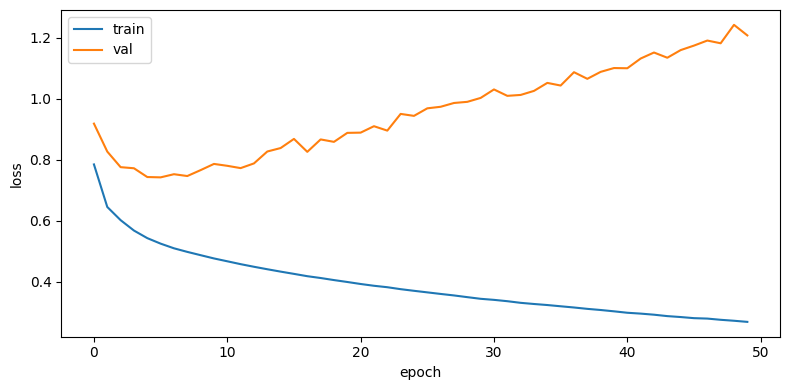

In [ ]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}

if not DATA_AVAILABLE:
    print("Training skipped: add Train_Dst_NoAuction_ZScore_CF_7.txt to Assignment2/raw.")
else:
    best_val = float("inf")
    for epoch in tqdm(range(cfg["epochs"]), desc="Epochs") :
        train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer)
        val_loss, val_acc = evaluate(model, loaders["val"], criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            torch.save(model.state_dict(), cfg["checkpoint_path"])
        if (epoch + 1) % 5 == 0 or improved:
            status = "*" if improved else " "
            print(f"Epoch {epoch+1:03d} {status} | train {train_loss:.4f} | val {val_loss:.4f} | val acc {val_acc:.4f}")
    print(f"Best val loss: {best_val:.4f}")

if history["train_loss"]:
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()

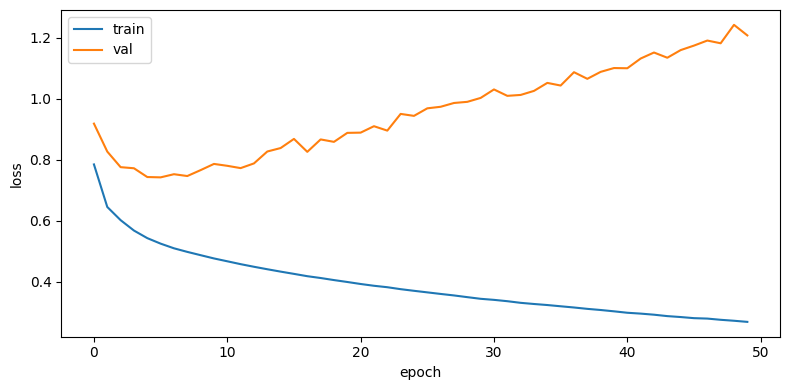

In [9]:
# Plot training curves (run after training finishes)
if history["train_loss"]:
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
else:
    print("No history to plot; run training first.")

In [8]:
if DATA_AVAILABLE and cfg["checkpoint_path"].exists():
    model.load_state_dict(torch.load(cfg["checkpoint_path"], map_location=device))
    test_loss, test_acc = evaluate(model, loaders["test"], criterion)
    print(f"Test loss {test_loss:.4f} | test acc {test_acc:.4f}")
else:
    print("Test skipped: checkpoint or data missing.")

Test loss 0.5559 | test acc 0.7900


Next steps: try other horizons (1,2,3,5,10), adjust learning rate/epochs, or compare with the TensorFlow reference if needed.